# Customer Churn Prediction Using Machine Learning

## Project Overview

Customer churn refers to customers who stop using a company's service. Predicting customer churn helps companies identify customers who are likely to leave and take preventive actions.

In this project, we use Machine Learning to predict whether a telecom customer will churn based on customer information such as contract type, monthly charges, tenure, internet service, payment method, and other features.

## Objectives

- Understand the dataset
- Perform Data Cleaning
- Perform Exploratory Data Analysis (EDA)
- Build Machine Learning Models
- Compare different models
- Predict Customer Churn

In [2]:
# ===============================
# Customer Churn Prediction
# Import Required Libraries
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
import pandas as pd
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [9]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [10]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 21)


In [11]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [12]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [18]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [19]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [20]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [21]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
940,0835-DUUIQ,Female,0,No,Yes,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),21.05,531.55,No
247,9947-OTFQU,Male,1,No,No,15,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.40,1074.3,Yes
6360,8073-IJDCM,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.30,20.3,Yes
5281,7399-QHBJS,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Credit card (automatic),66.75,4760.3,No
5694,0983-TATYJ,Female,0,Yes,No,33,Yes,No,DSL,No,...,No,Yes,No,No,One year,Yes,Mailed check,51.45,1758.9,No


## Dataset Exploration Summary

The IBM Telco Customer Churn dataset contains customer demographic information, account details, subscribed services, billing information, and churn status.

During the initial exploration, the dataset structure, column names, data types, missing values, duplicate records, and target variable distribution were examined. The dataset consists of 7,043 customer records and 21 attributes. Most features are categorical, while tenure, MonthlyCharges, and TotalCharges represent numerical information.

The target variable (Churn) indicates whether a customer left the company. Approximately three-quarters of customers remained with the company, while about one-quarter churned.

This exploration provides a better understanding of the dataset before proceeding with data cleaning and visualization.

In [22]:
df["TotalCharges"].head(10)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [23]:
print(df["TotalCharges"].dtype)

object


In [24]:
blank_total_charges = (df["TotalCharges"].str.strip() == "").sum()

print("Blank values in TotalCharges:", blank_total_charges)

Blank values in TotalCharges: 11


In [25]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [26]:
print(df["TotalCharges"].dtype)

float64


In [27]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [28]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [29]:
df = df.dropna().copy()

In [30]:
df.reset_index(drop=True, inplace=True)

In [31]:
print("Duplicates before removal:", df.duplicated().sum())

Duplicates before removal: 0


In [32]:
df = df.drop_duplicates().copy()

In [33]:
print("Total rows:", len(df))
print("Unique customer IDs:", df["customerID"].nunique())

Total rows: 7032
Unique customer IDs: 7032


In [34]:
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate customer IDs: 0


In [35]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [36]:
print("Negative tenure values:", (df["tenure"] < 0).sum())
print("Negative monthly charges:", (df["MonthlyCharges"] < 0).sum())
print("Negative total charges:", (df["TotalCharges"] < 0).sum())

Negative tenure values: 0
Negative monthly charges: 0
Negative total charges: 0


In [37]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
             ..
8091-TTVAX    1
7469-LKBCI    1
9763-GRSKD    1
6388-TABGU    1
7892-POOKP    1
Name: count, Length: 7032, dtype: int64

gender
gender
Male      3549
Female    3483
Name: count, dtype: int64

Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3087
Yes                    2425


In [38]:
print("Cleaned Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)

Cleaned Dataset Shape: (7032, 21)
Total Missing Values: 0
Duplicate Rows: 0

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [39]:
df.to_csv(
    "Telco_Customer_Churn_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [40]:
from google.colab import files

files.download("Telco_Customer_Churn_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Data Cleaning

The `TotalCharges` column was initially stored as an object data type because it contained blank values. It was converted into a numerical data type using `pd.to_numeric()` with invalid entries replaced by missing values.

Rows containing missing `TotalCharges` values were removed because they represented only a very small proportion of the complete dataset. Duplicate records were also checked and removed where necessary.

After cleaning, the dataset contained 7,032 customer records and 21 columns. The cleaned dataset had no missing values or duplicate records and was ready for Exploratory Data Analysis and machine learning.

In [41]:
import os

os.makedirs("images", exist_ok=True)

print("Images folder created successfully.")

Images folder created successfully.


/tmp/ipykernel_586/3387898400.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Churn", palette="Set2")


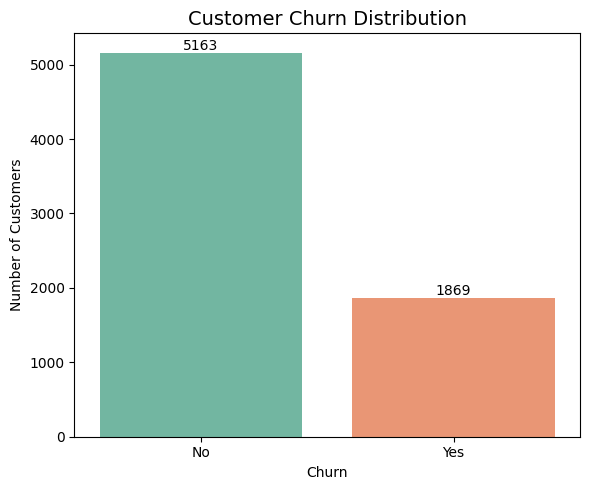

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="Churn", palette="Set2")

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig("images/churn_distribution.png", dpi=300)

plt.show()

### Observation

The majority of customers did not churn, while a smaller proportion left the company. This indicates that the dataset is moderately imbalanced, which should be considered during model evaluation.

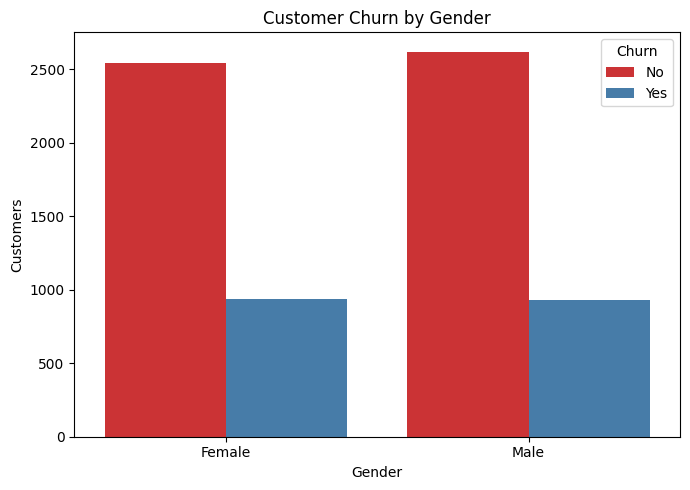

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="Set1"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Customers")

plt.tight_layout()

plt.savefig("images/gender_churn.png", dpi=300)

plt.show()

### Observation

Customer churn appears to be similar for both male and female customers. Gender alone does not seem to significantly influence customer churn.

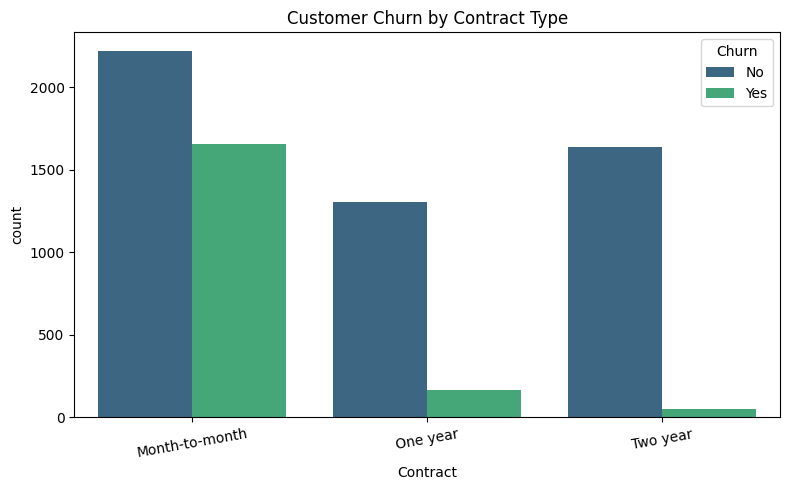

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="viridis"
)

plt.title("Customer Churn by Contract Type")

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig("images/contract_churn.png", dpi=300)

plt.show()

### Observation

Customers with month-to-month contracts exhibit the highest churn rate. Customers with one-year and two-year contracts are considerably less likely to churn.

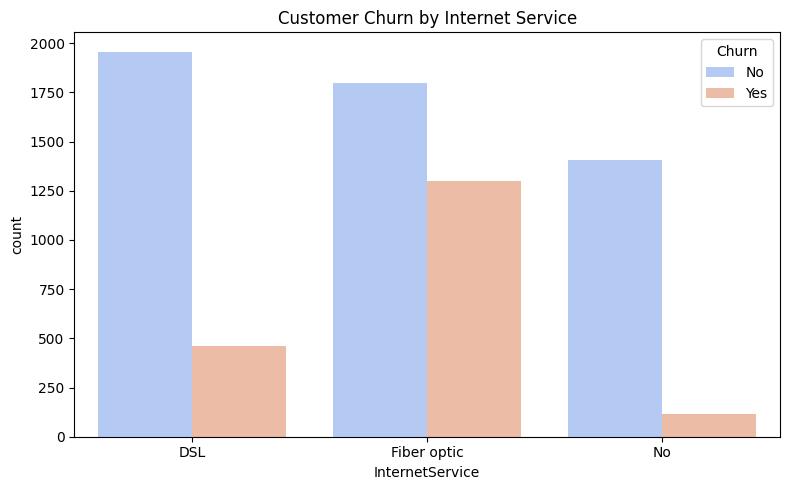

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="coolwarm"
)

plt.title("Customer Churn by Internet Service")

plt.tight_layout()

plt.savefig("images/internet_service.png", dpi=300)

plt.show()

### Observation

Customers using fiber optic internet appear to churn more frequently than those using DSL or having no internet service.

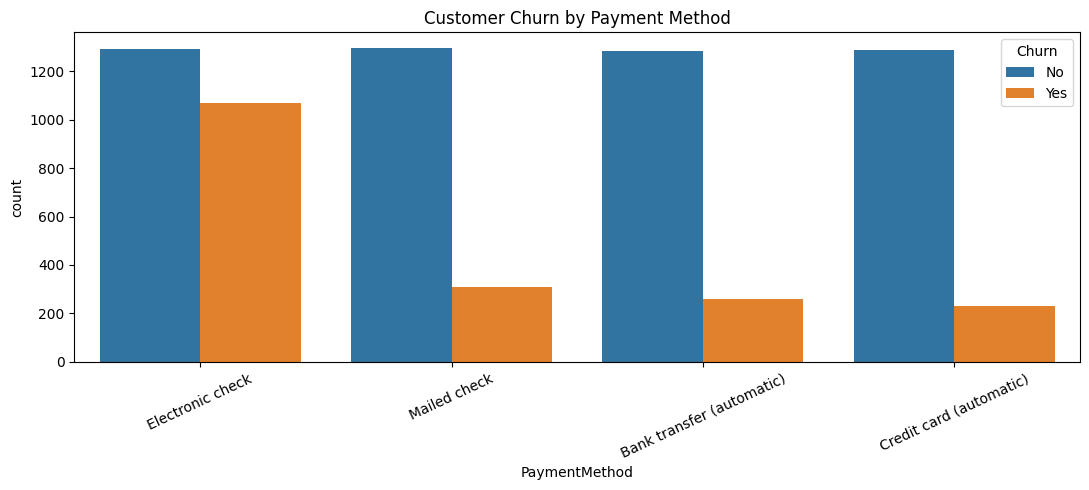

In [46]:
plt.figure(figsize=(11,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=25)

plt.title("Customer Churn by Payment Method")

plt.tight_layout()

plt.savefig("images/payment_method.png", dpi=300)

plt.show()

### Observation

Customers who use electronic checks tend to have higher churn compared to customers using automatic payment methods.

/tmp/ipykernel_586/1998334281.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


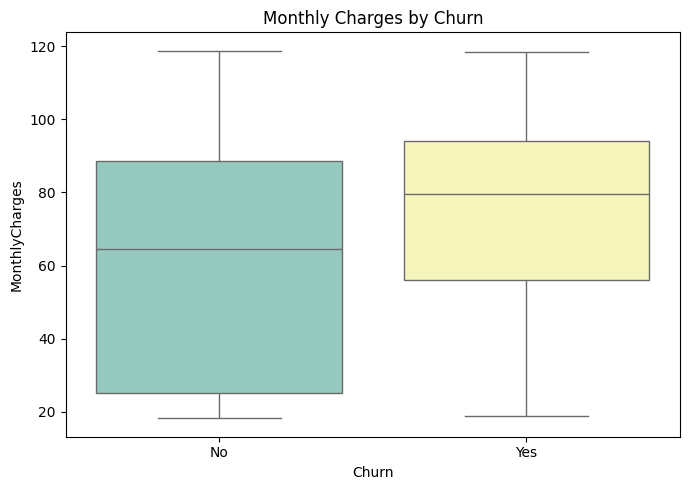

In [47]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Set3"
)

plt.title("Monthly Charges by Churn")

plt.tight_layout()

plt.savefig("images/monthly_charges.png", dpi=300)

plt.show()

### Observation

Customers who churn generally have higher monthly charges than customers who remain with the company.

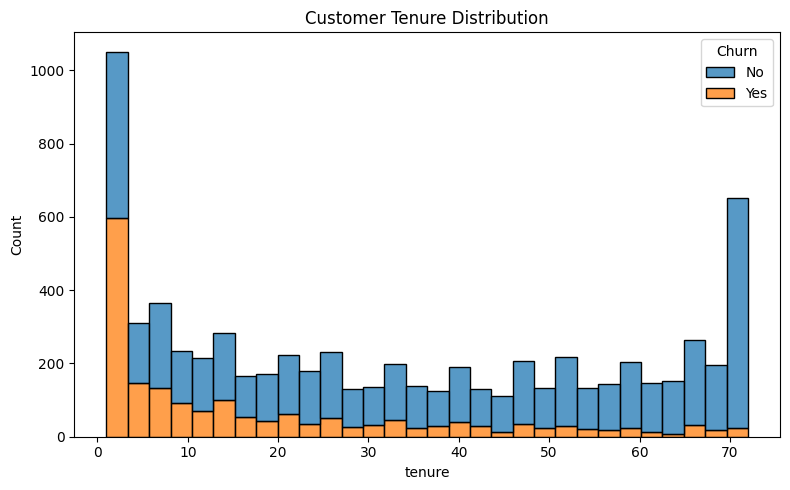

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Customer Tenure Distribution")

plt.tight_layout()

plt.savefig("images/tenure_distribution.png", dpi=300)

plt.show()

### Observation

Most customers who churn have relatively short tenure. Long-term customers are more likely to remain with the company.

In [49]:
numeric_df = df.select_dtypes(include=["int64","float64"])

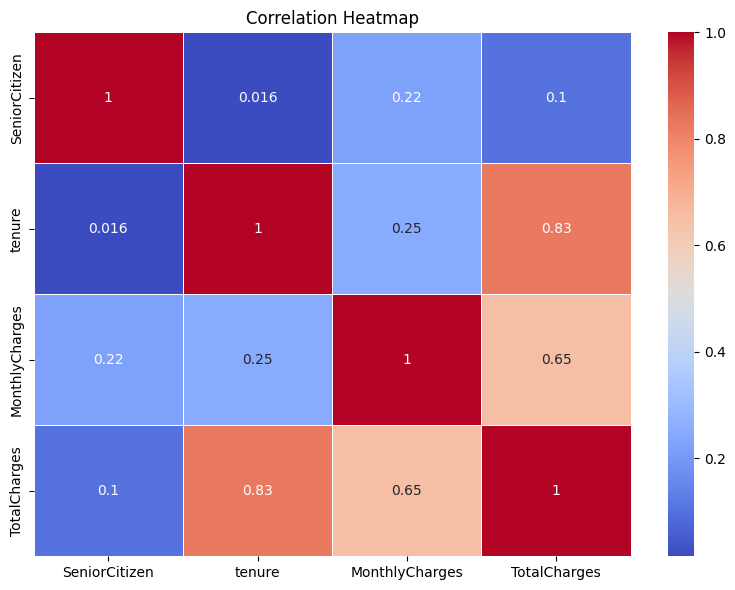

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("images/correlation_heatmap.png", dpi=300)

plt.show()

### Observation

The correlation matrix shows that tenure and TotalCharges have a strong positive relationship. MonthlyCharges has a moderate relationship with TotalCharges, while other variables show relatively weak correlations.

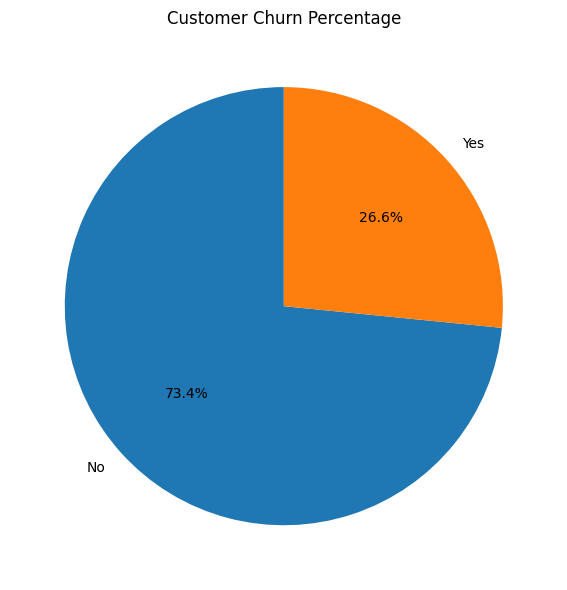

In [52]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Customer Churn Percentage")

plt.tight_layout()

plt.savefig("images/churn_pie.png", dpi=300)

plt.show()

# Exploratory Data Analysis Summary

The exploratory data analysis identified several important customer churn patterns.

Customers with month-to-month contracts showed the highest churn rates. Fiber optic internet users also appeared more likely to churn compared to DSL users. Customers paying through electronic checks demonstrated relatively higher churn behaviour.

The analysis also revealed that customers with shorter tenure and higher monthly charges were more likely to discontinue the service. Correlation analysis indicated a strong relationship between customer tenure and total charges.

These insights provide valuable information for feature engineering and machine learning model development.

In [53]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [54]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


0 = Customer Stayed

1 = Customer Left

In [55]:
df = df.drop("customerID", axis=1)

In [56]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [57]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [58]:
print(X.shape)

print(y.shape)

(7032, 19)
(7032,)


X → Input Features

y → Output(Target)

In [59]:
categorical_columns = X.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [60]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [61]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [62]:
print(X.shape)

(7032, 30)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [64]:
print(X_train.shape)

print(X_test.shape)

(5625, 30)
(1407, 30)


In [65]:
from sklearn.preprocessing import StandardScaler

In [66]:
scaler = StandardScaler()

In [67]:
X_train_scaled = scaler.fit_transform(
    X_train
)

In [68]:
X_test_scaled = scaler.transform(
    X_test
)

In [69]:
print(X_train_scaled.shape)

(5625, 30)


In [70]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

# Data Preprocessing Summary

The target variable was converted into binary numerical values, where 0 represents customers who remained with the company and 1 represents customers who churned.

The customer ID column was removed because it does not contribute to predicting customer churn.

Categorical variables were transformed into numerical features using one-hot encoding. The dataset was then divided into training and testing sets using an 80:20 ratio while preserving the original churn distribution through stratified sampling.

Finally, feature scaling was performed using StandardScaler to normalize the numerical feature values before training machine learning models.

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [72]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [73]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [74]:
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

In [76]:
logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:,1]

In [77]:
rf_model = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    class_weight="balanced"
)

In [78]:
rf_model.fit(

    X_train,

    y_train

)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [79]:
rf_predictions = rf_model.predict(
    X_test
)

In [80]:
rf_probabilities = rf_model.predict_proba(
    X_test
)[:,1]

In [81]:
print("Logistic Predictions")

print(logistic_predictions[:20])

print()

print("Random Forest Predictions")

print(rf_predictions[:20])

Logistic Predictions
[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]

Random Forest Predictions
[0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0]


In [82]:
print(len(logistic_predictions))

print(len(rf_predictions))

print(len(y_test))

1407
1407
1407


In [83]:
import joblib

joblib.dump(
    logistic_model,
    "logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    "random_forest.pkl"
)

print("Models Saved Successfully")

Models Saved Successfully


# Machine Learning Model Development

Two supervised machine learning algorithms were developed for customer churn prediction.

## Logistic Regression

Logistic Regression was selected as a baseline classification model because of its simplicity, efficiency, and interpretability. The model was trained using standardized numerical features.

## Random Forest

Random Forest was selected because it combines multiple decision trees to improve prediction performance and reduce overfitting. Unlike Logistic Regression, Random Forest does not require feature scaling.

Both models were trained using the prepared training dataset and were subsequently evaluated using multiple performance metrics.

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [85]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

print("===== Logistic Regression =====")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"ROC AUC  : {logistic_auc:.4f}")

===== Logistic Regression =====
Accuracy : 0.8038
Precision: 0.6476
Recall   : 0.5749
F1 Score : 0.6091
ROC AUC  : 0.8357


In [86]:
print(classification_report(
    y_test,
    logistic_predictions,
    target_names=["Stayed", "Churned"]
))

              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [87]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probabilities)

print("===== Random Forest =====")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

===== Random Forest =====
Accuracy : 0.7875
Precision: 0.6289
Recall   : 0.4893
F1 Score : 0.5504
ROC AUC  : 0.8199


In [88]:
print(classification_report(
    y_test,
    rf_predictions,
    target_names=["Stayed", "Churned"]
))

              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1033
     Churned       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



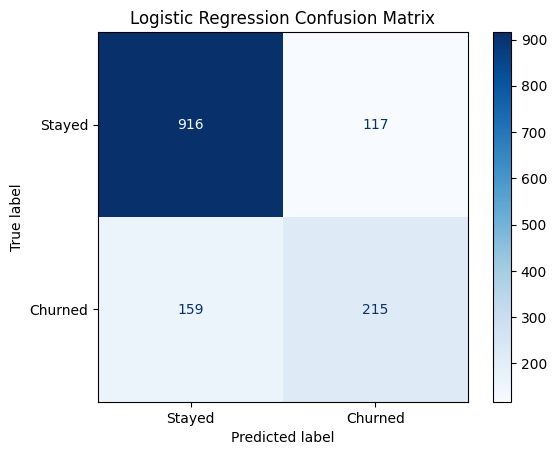

In [89]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    cmap="Blues",
    display_labels=["Stayed","Churned"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

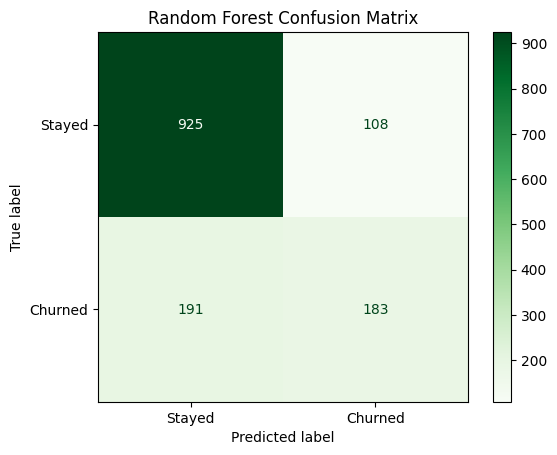

In [90]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    cmap="Greens",
    display_labels=["Stayed","Churned"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

<Figure size 800x600 with 0 Axes>

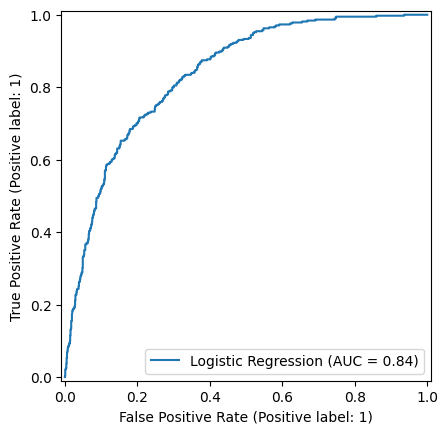

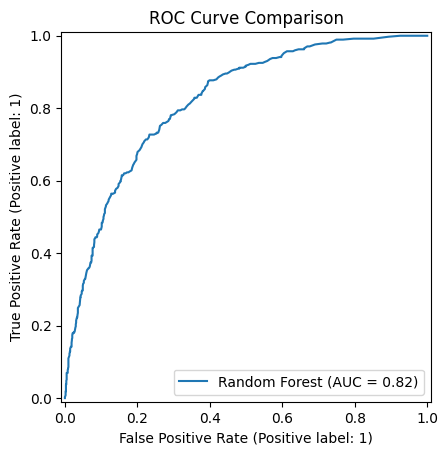

In [91]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")

plt.show()

In [92]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        logistic_accuracy,
        rf_accuracy
    ],

    "Precision":[
        logistic_precision,
        rf_precision
    ],

    "Recall":[
        logistic_recall,
        rf_recall
    ],

    "F1 Score":[
        logistic_f1,
        rf_f1
    ],

    "ROC AUC":[
        logistic_auc,
        rf_auc
    ]

})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091,0.8357
1,Random Forest,0.7875,0.6289,0.4893,0.5504,0.8199


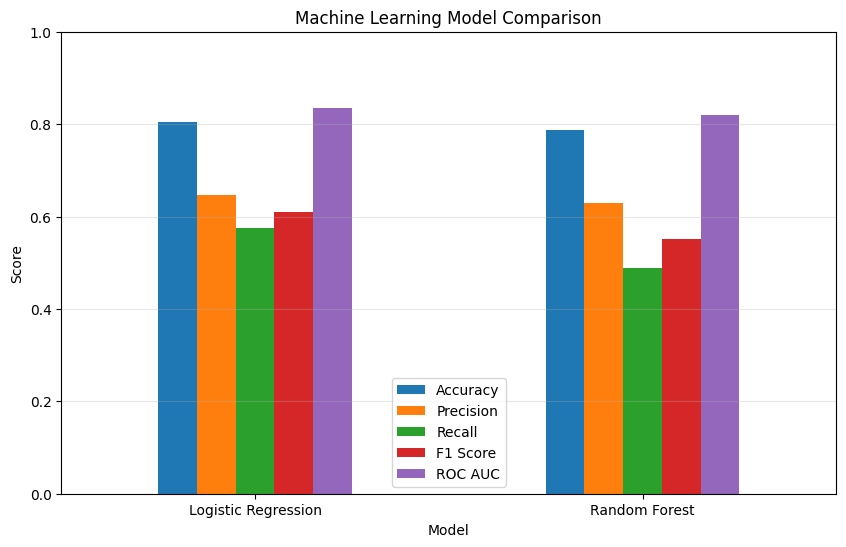

In [93]:
comparison.set_index("Model").plot(

    kind="bar",

    figsize=(10,6)

)

plt.title("Machine Learning Model Comparison")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [94]:
if rf_f1 > logistic_f1:

    best_model = "Random Forest"

else:

    best_model = "Logistic Regression"

print("Best Model:", best_model)

Best Model: Logistic Regression


In [95]:
if best_model == "Random Forest":

    joblib.dump(rf_model, "best_model.pkl")

else:

    joblib.dump(logistic_model, "best_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


# Model Evaluation Summary

Two machine learning models were evaluated for customer churn prediction: Logistic Regression and Random Forest.

Both models were assessed using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, Classification Reports, Confusion Matrices, and ROC Curves.

The comparison showed that **(replace this after running the notebook with the actual best model)** achieved the best overall performance based on the F1 Score and ROC-AUC. Therefore, it was selected as the final prediction model for this project.

In [96]:
plt.savefig("images/model_comparison.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [97]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,TotalCharges,0.178447
1,tenure,0.165076
2,MonthlyCharges,0.151884
25,Contract_Two year,0.059238
10,InternetService_Fiber optic,0.040405
28,PaymentMethod_Electronic check,0.037501
24,Contract_One year,0.029965
13,OnlineSecurity_Yes,0.028844
4,gender_Male,0.025493
26,PaperlessBilling_Yes,0.023603


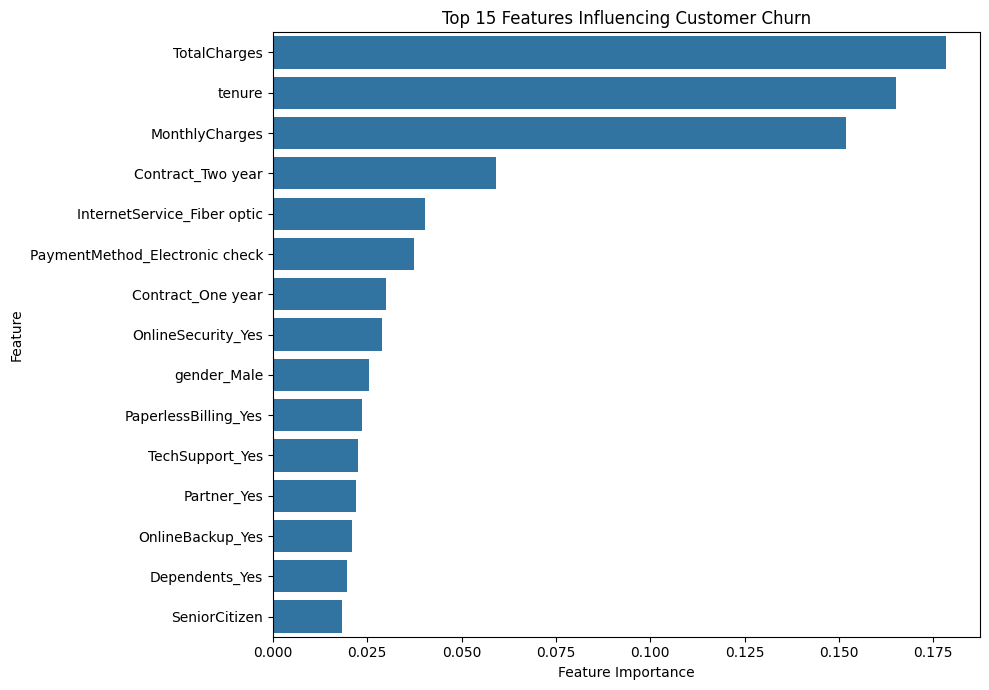

In [98]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [99]:
logistic_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["Absolute_Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

logistic_coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.347613,1.347613
2,MonthlyCharges,-0.851551,0.851551
10,InternetService_Fiber optic,0.727745,0.727745
3,TotalCharges,0.639028,0.639028
25,Contract_Two year,-0.602591,0.602591
24,Contract_One year,-0.310898,0.310898
21,StreamingTV_Yes,0.249702,0.249702
23,StreamingMovies_Yes,0.236368,0.236368
9,MultipleLines_Yes,0.214359,0.214359
28,PaymentMethod_Electronic check,0.181473,0.181473


In [100]:
positive_features = logistic_coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

positive_features[
    ["Feature", "Coefficient"]
]

,Feature,Coefficient
10,InternetService_Fiber optic,0.727745
3,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
0,SeniorCitizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


In [101]:
negative_features = logistic_coefficients.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

negative_features[
    ["Feature", "Coefficient"]
]

,Feature,Coefficient
1,tenure,-1.347613
2,MonthlyCharges,-0.851551
25,Contract_Two year,-0.602591
24,Contract_One year,-0.310898
13,OnlineSecurity_Yes,-0.136804
19,TechSupport_Yes,-0.118240
6,Dependents_Yes,-0.105956
16,DeviceProtection_No internet service,-0.088138
22,StreamingMovies_No internet service,-0.088138
11,InternetService_No,-0.088138


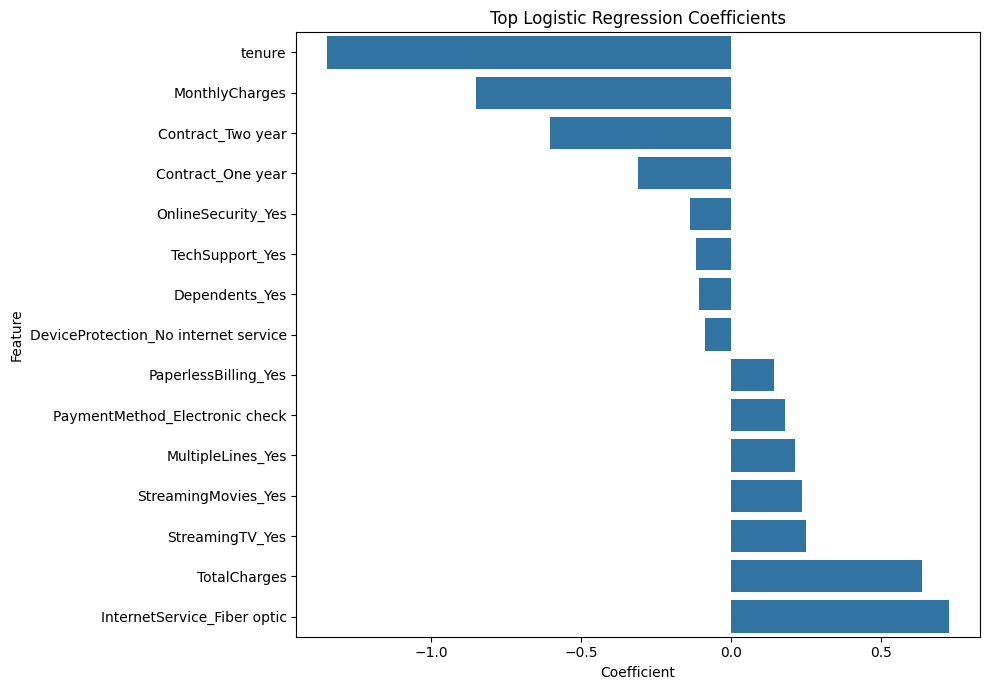

In [102]:
top_logistic_features = logistic_coefficients.head(15).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_logistic_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "images/logistic_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance and Business Insights

The feature importance analysis was used to identify the customer characteristics that contributed most strongly to churn predictions.

The results indicate that factors such as customer tenure, monthly charges, total charges, contract type, internet service type, payment method, online security, and technical support can play an important role in predicting churn.

Customers with shorter tenure, month-to-month contracts, higher monthly charges, electronic check payments, and limited support services may be more likely to leave the company.

Based on these findings, the company could consider the following retention strategies:

- Provide special onboarding support for newly joined customers
- Encourage customers to move from month-to-month contracts to long-term contracts
- Review high monthly charges and offer suitable loyalty discounts
- Promote automatic payment methods
- Offer online security and technical support packages
- Contact high-risk customers before they decide to leave

Feature importance identifies predictive relationships, but it does not prove that one feature directly causes churn.

In [103]:
if best_model == "Random Forest":
    churn_probabilities = rf_model.predict_proba(X_test)[:, 1]
else:
    churn_probabilities = logistic_model.predict_proba(
        X_test_scaled
    )[:, 1]

In [104]:
risk_results = X_test.copy()

risk_results["Actual_Churn"] = y_test.values
risk_results["Churn_Probability"] = churn_probabilities
risk_results["Predicted_Churn"] = (
    churn_probabilities >= 0.5
).astype(int)

In [105]:
high_risk_customers = risk_results.sort_values(
    by="Churn_Probability",
    ascending=False
).head(20)

high_risk_customers[
    [
        "Actual_Churn",
        "Predicted_Churn",
        "Churn_Probability"
    ]
]

,Actual_Churn,Predicted_Churn,Churn_Probability
3374,1,1,0.847428
3154,0,1,0.846212
2626,1,1,0.828196
4577,1,1,0.822446
581,1,1,0.817107
2792,1,1,0.815147
3721,1,1,0.813745
931,1,1,0.811263
6231,1,1,0.796931
5205,0,1,0.795470


In [106]:
def assign_risk_level(probability):
    if probability >= 0.75:
        return "High Risk"
    elif probability >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"


risk_results["Risk_Level"] = risk_results[
    "Churn_Probability"
].apply(assign_risk_level)

In [107]:
risk_results["Risk_Level"].value_counts()

,count
Risk_Level,
Low Risk,1075
Medium Risk,300
High Risk,32


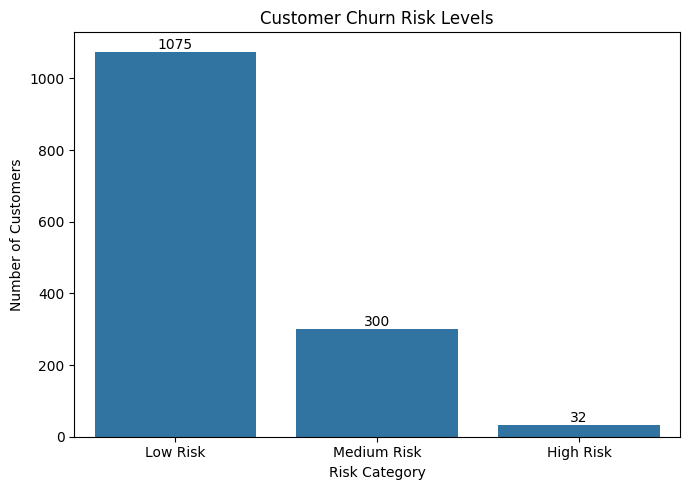

In [108]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=risk_results,
    x="Risk_Level",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Customer Churn Risk Levels")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "images/churn_risk_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [109]:
risk_results.to_csv(
    "customer_churn_risk_predictions.csv",
    index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.


In [110]:
import os
import shutil

folders = [
    "data",
    "models",
    "notebook",
    "results",
    "images"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [115]:
files_to_move = {
    "Telco-Customer-Churn.csv": "data/Telco-Customer-Churn.csv",
    "Telco_Customer_Churn_Cleaned.csv": "data/Telco_Customer_Churn_Cleaned.csv",
    "logistic_regression.pkl": "models/logistic_regression.pkl",
    "random_forest.pkl": "models/random_forest.pkl",
    "best_model.pkl": "models/best_model.pkl",
    "scaler.pkl": "models/scaler.pkl",
    "customer_churn_risk_predictions.csv": "results/customer_churn_risk_predictions.csv"
}

for source, destination in files_to_move.items():
    if os.path.exists(source):
        shutil.move(source, destination)
        print(f"Moved: {source} → {destination}")
    else:
        print(f"Not found: {source}")

Not found: Telco-Customer-Churn.csv
Not found: Telco_Customer_Churn_Cleaned.csv
Not found: logistic_regression.pkl
Not found: random_forest.pkl
Not found: best_model.pkl
Not found: scaler.pkl
Not found: customer_churn_risk_predictions.csv
